1. Create and plot a correlation matrix for the output variables G1, G2 and G3 for the student
performance data.

In [14]:
import pandas as pd
from itables import show

stud = pd.read_csv("student-mat.csv", sep=";")
corr = stud[["G1", "G2", "G3"]].corr()
corr.style.background_gradient(cmap="coolwarm_r", axis=None, vmax=1, vmin=-1)


,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


2. Using the columns G1, G2 and G3, create a new dataframe with 2 columns: grade_type and
grade_score. There should be 395 × 3 = 1185 rows in the new dataframe. The unique values in
grade_type column should be final, second and first. 

In [6]:
sad = {"G1": "first", "G2": "second", "G3": "final"}

scores = stud[["G1", "G2", "G3"]]

show(scores)

res = pd.DataFrame(columns=["grade_type", "grade_score"])

for row in scores.values:
    for i in range(len(row)):
        df2 = pd.DataFrame([[sad.get(scores.columns[i]), row[i]]], columns=["grade_type", "grade_score"])
        res = pd.concat([res,df2])

custom_order = {'first': 1, 'second': 2, 'final': 3}

res.sort_values(inplace=True, by=["grade_type"], key=lambda col: col.map(custom_order))
show(res)


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


In [11]:
#wow
grade_score = ([
    stud[["G1", "G2", "G3"]].rename(
        columns={"G1":"first", "G2" : "second", "G3" : "final"}
    )
    .melt(var_name="grade_type", value_name="grade_score")
])

show(grade_score[0])


Loading ITables v2.6.2 from the internet... (need help?)


array([[<Axes: title={'center': 'G1'}>, <Axes: title={'center': 'G2'}>],
       [<Axes: title={'center': 'G3'}>, <Axes: >]], dtype=object)

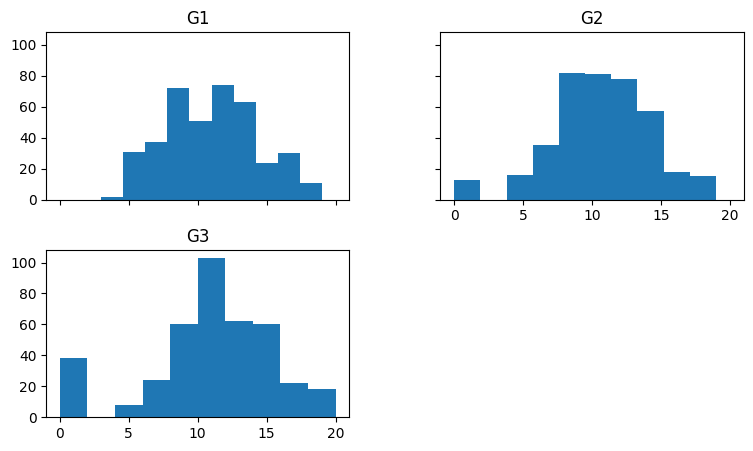

In [3]:
scores.hist(grid=False, sharex=True, sharey=True, figsize=(9,5))

[25 54 26 56 24 28 22 21 75 22 30 38 22 40 23]
count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64


Loading ITables v2.6.2 from the internet... (need help?)


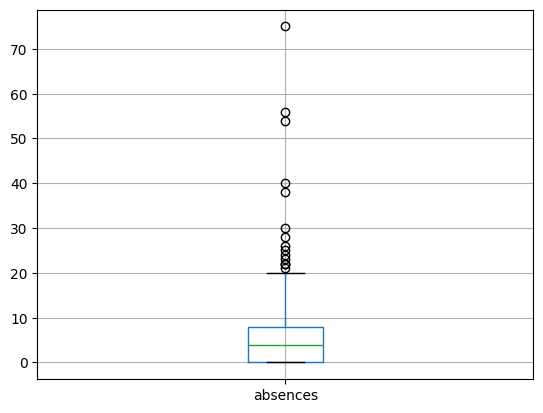

In [17]:
import numpy as np
sad = stud.boxplot(column="absences", return_type='dict')

gae = stud["absences"].describe()

print(sad['fliers'][0].get_ydata())

print(gae)

iqr = np.quantile(stud["absences"], 0.75) - np.quantile(stud["absences"], 0.25)
upper = stud[stud["absences"] > np.quantile(stud["absences"], 0.75) + 1.5 * iqr]

show(upper)

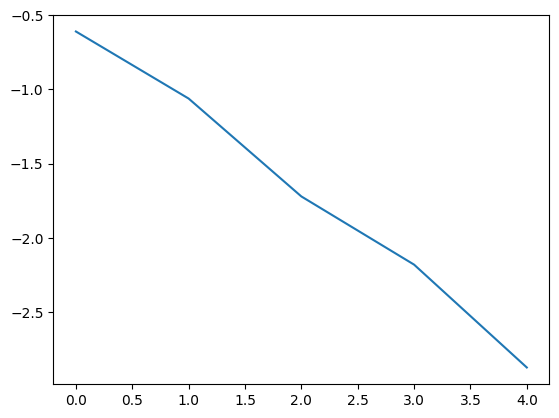

: 

In [ ]:
import math
import matplotlib.pyplot as plt

er_arrivals = pd.read_csv("er_arrivals.csv")

unique = er_arrivals["num_arrivals"].value_counts()

est = []

for i in range(len(unique)):
    est.append(math.log(math.factorial(i) * unique[i] / sum(unique)))

sad = np.array(est)

plt.plot(sad)
